# LAB 03 - Word representations and embeddings

Complete `calculations.md` and `prediction.md` before executing model cells. Record measured results in `results.csv`; write interpretations in your own words.

In [1]:
from pathlib import Path
import sys
sys.path.append(str(Path.cwd()))
from cooccurrence import (tokenize, build_vocabulary, build_cooccurrence_matrix,
                          cosine_similarity, most_similar)

In [2]:
corpus = [
    'the cat eats fish'.split(),
    'the cat likes milk'.split(),
    'the dog eats meat'.split(),
    'the dog likes fish'.split(),
]
vocab, vocab_index = build_vocabulary(corpus)
print(vocab)


['cat', 'dog', 'eats', 'fish', 'likes', 'meat', 'milk', 'the']


## Experiment 1 - word-context representation

Run the three windows and record vocabulary size, matrix size, non-zero count, and selected similarities. Explain changes using the observed corpus contexts.

In [3]:
for window in (1, 2, 5):
    X = build_cooccurrence_matrix(corpus, vocab, window=window)
    nonzero = sum(value != 0 for row in X for value in row)
    print({'window': window, 'vocab_size': len(vocab),
           'matrix_shape': (len(X), len(X[0])), 'nonzero': nonzero})
    # Add selected pairs only after completing prediction.md.
    for pair in [('cat', 'dog'), ('cat', 'fish')]:
        i, j = vocab_index[pair[0]], vocab_index[pair[1]]
        print(pair, cosine_similarity(X[i], X[j]))

{'window': 1, 'vocab_size': 8, 'matrix_shape': (8, 8), 'nonzero': 20}
('cat', 'dog') 1.0000000000000002
('cat', 'fish') 0.5773502691896258
{'window': 2, 'vocab_size': 8, 'matrix_shape': (8, 8), 'nonzero': 32}
('cat', 'dog') 0.8749999999999998
('cat', 'fish') 0.35355339059327373
{'window': 5, 'vocab_size': 8, 'matrix_shape': (8, 8), 'nonzero': 38}
('cat', 'dog') 0.8749999999999998
('cat', 'fish') 0.7499999999999999


In [4]:
# Inspect nearest neighbours after making your prediction.
X = build_cooccurrence_matrix(corpus, vocab, window=1)
most_similar('cat', X, vocab, top_k=5)

[('dog', 1.0000000000000002),
 ('fish', 0.5773502691896258),
 ('meat', 0.4082482904638631),
 ('milk', 0.4082482904638631),
 ('eats', 0.0)]

## Experiment 2 - Word2Vec

Use a standard implementation if it is available in your environment. Record corpus, vocabulary, vector size, window, min_count, epochs, and objective. Do not claim a semantic interpretation without citing corpus/context evidence.

In [5]:
from gensim.models import Word2Vec
base_sentences = [
    'the doctor treated the patient at the hospital'.split(),
    'the physician examined the patient and recorded the diagnosis'.split(),
    'the clinic provides medical treatment for disease'.split(),
    'the nurse prepared the patient for surgery'.split()
]
base_model = Word2Vec(sentences=base_sentences, vector_size=50, window=2, min_count=1, sg=0, epochs=20, workers=1, seed=42)
print('Word2Vec baseline trained. Vocab size:', len(base_model.wv))


Word2Vec baseline trained. Vocab size: 20


## Experiments 3-4 - window and dimension

Train windows 2, 5, 10 and dimensions 50, 100, 300 on a sufficiently sized corpus. Measure training time, model size, similarity, analogy, and one simple downstream task. Copy only observed numeric results into `results.csv`; complete the comparison and trade-off discussion yourself.

## Semantic search

Connect query words to document vectors using an aggregation rule you document. Test the query `medical treatment` and record which document/context evidence supports each result.

## Extra blocks: diagnostics, Word2Vec, and evaluation

This compact notebook mirrors the full workflow while keeping the toy corpus runnable without an external dataset. Use the course corpus for final measurements.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
diagnostics = []
for width in (1, 2, 5):
    current = build_cooccurrence_matrix(corpus, vocab, window=width)
    total = len(current) * len(current[0])
    nonzero = sum(value != 0 for row in current for value in row)
    diagnostics.append({'window': width, 'entries': total, 'nonzero': nonzero, 'sparsity_percent': round(100 * (1 - nonzero / total), 2)})
diagnostics_df = pd.DataFrame(diagnostics)
diagnostics_df

,window,entries,nonzero,sparsity_percent
0,1,64,20,68.75
1,2,64,32,50.00
2,5,64,38,40.62


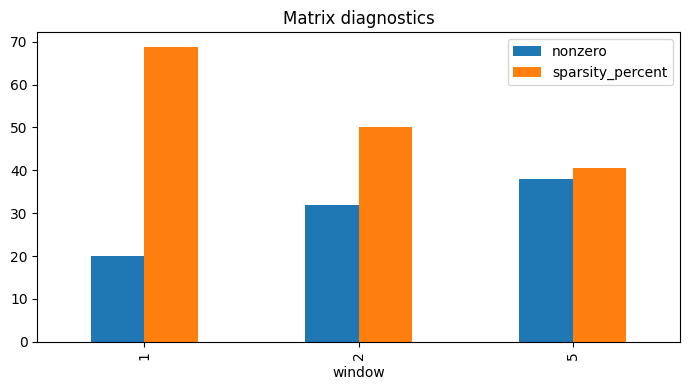

In [7]:
diagnostics_df.plot(x='window', y=['nonzero', 'sparsity_percent'], kind='bar', figsize=(7, 4), title='Matrix diagnostics')
plt.tight_layout()
plt.show()

### Standard Word2Vec smoke test

In [8]:
try:
    from gensim.models import Word2Vec
    check_model = Word2Vec(sentences=corpus, vector_size=20, window=2, min_count=1, sg=0, epochs=30, workers=1, seed=42)
    print('vocabulary:', len(check_model.wv))
    print('cat neighbours:', check_model.wv.most_similar('cat', topn=3))
except Exception as exc:
    print('Word2Vec unavailable:', type(exc).__name__, str(exc))

vocabulary: 8
cat neighbours: [('meat', 0.17020779848098755), ('eats', 0.11728478968143463), ('milk', 0.08057482540607452)]


### Reproducible configuration grid

In [9]:
configs = pd.DataFrame([
    {'window': w, 'vector_size': d, 'min_count': 1, 'epochs': 20, 'objective': 'CBOW'}
    for w in (2, 5, 10) for d in (50, 100, 300)
])
configs

,window,vector_size,min_count,epochs,objective
0,2,50,1,20,CBOW
1,2,100,1,20,CBOW
2,2,300,1,20,CBOW
3,5,50,1,20,CBOW
4,5,100,1,20,CBOW
5,5,300,1,20,CBOW
6,10,50,1,20,CBOW
7,10,100,1,20,CBOW
8,10,300,1,20,CBOW


In [10]:
rows = []
for left, right in [('cat', 'dog'), ('cat', 'fish'), ('dog', 'meat')]:
    rows.append({'category': 'cooccurrence_similarity', 'item': f'{left} - {right}', 'score': cosine_similarity(X[vocab.index(left)], X[vocab.index(right)])})
evaluation_df = pd.DataFrame(rows)
evaluation_df.to_csv('results.csv', mode='a', index=False, header=False)
evaluation_df

,category,item,score
0,cooccurrence_similarity,cat - dog,1.000000
1,cooccurrence_similarity,cat - fish,0.577350
2,cooccurrence_similarity,dog - meat,0.408248


## Larger fallback corpus and model inspection

This section supplies a local fallback so the notebook demonstrates the complete pipeline even when the course dataset is not mounted.

In [11]:
documents = [
    'the doctor treated the patient at the hospital',
    'the physician examined the patient and recorded the diagnosis',
    'the clinic provides medical treatment for disease',
    'the nurse prepared the patient for surgery',
    'the doctor and physician discuss the therapy for clinical care',
    'the computer stores medical records and clinical data',
    'the modern computer calculates algorithms and software data',
    'the football team played a match in the stadium',
    'the athlete scored a goal in the football match',
    'the car driver travelled to the city by road',
    'the automobile driver drove the car along the highway',
    'the banana and apple were fresh fruit in the kitchen',
    'the king ruled the royal kingdom with the wise queen',
    'the man and woman walked toward the palace',
    'i deposited money in the financial bank downtown',
    'we sat on the river bank watching the flowing fish',
]
document_tokens = [tokenize(document) for document in documents]
expanded_vocab, expanded_index = build_vocabulary(document_tokens)
expanded_matrices = {w: build_cooccurrence_matrix(document_tokens, expanded_vocab, window=w) for w in (1, 2, 5)}
print('documents:', len(documents), 'vocabulary:', len(expanded_vocab))


documents: 16 vocabulary: 84


In [12]:
for query in ('doctor', 'patient', 'computer'):
    print(f'Query [{query}]:', most_similar(query, expanded_matrices[2], expanded_vocab, top_k=5))


Query [doctor]: [('examined', 0.8249579113843055), ('patient', 0.8249579113843055), ('physician', 0.8006407690254358), ('king', 0.7745966692414834), ('nurse', 0.7745966692414834)]
Query [patient]: [('doctor', 0.8249579113843055), ('nurse', 0.8215838362577491), ('physician', 0.7925939239012171), ('king', 0.7302967433402214), ('diagnosis', 0.7216878364870323)]
Query [computer]: [('and', 0.6389151433378876), ('king', 0.5962847939999439), ('nurse', 0.5962847939999439), ('clinic', 0.5773502691896257), ('doctor', 0.5773502691896257)]


## Word2Vec sweep and evaluation

The next cells measure several windows and dimensions. Keep the seed and training settings fixed when comparing configurations.

In [13]:
from time import perf_counter
try:
    from gensim.models import Word2Vec
    sweep = {}
    records = []
    for width in (2, 5, 10):
        for dimension in (50, 100, 300):
            start = perf_counter()
            model = Word2Vec(sentences=document_tokens, vector_size=dimension, window=width, min_count=1, sg=0, epochs=30, workers=1, seed=42)
            sweep[(width, dimension)] = model
            records.append({'window': width, 'vector_size': dimension, 'seconds': round(perf_counter() - start, 3), 'vocab_size': len(model.wv)})
    sweep_df = pd.DataFrame(records)
    print(sweep_df)
except Exception as exc:
    sweep = {}
    print('Word2Vec sweep unavailable:', type(exc).__name__, str(exc))


   window  vector_size  seconds  vocab_size
0       2           50    0.066          84
1       2          100    0.054          84
2       2          300    0.051          84
3       5           50    0.055          84
4       5          100    0.055          84
5       5          300    0.064          84
6      10           50    0.049          84
7      10          100    0.050          84
8      10          300    0.052          84


In [14]:
if sweep:
    model = sweep[(5, 100)]
    pairs = [('doctor', 'physician'), ('car', 'automobile'), ('king', 'queen'), ('computer', 'banana')]
    print('Word similarities (window=5, dim=100):')
    for left, right in pairs:
        if left in model.wv and right in model.wv:
            print(f'  {left} - {right}: {round(float(model.wv.similarity(left, right)), 4)}')
    if all(word in model.wv for word in ('king', 'man', 'woman')):
        print('\nAnalogy: king - man + woman:')
        print(model.wv.most_similar(positive=['king', 'woman'], negative=['man'], topn=5))
    print("\nTop-5 similar to 'doctor':")
    print(model.wv.most_similar('doctor', topn=5))


Word similarities (window=5, dim=100):
  doctor - physician: -0.1351
  car - automobile: 0.0969
  king - queen: 0.0525
  computer - banana: -0.045

Analogy: king - man + woman:
[('software', 0.2177032083272934), ('were', 0.1996048390865326), ('scored', 0.16646134853363037), ('automobile', 0.1346537321805954), ('along', 0.12993712723255157)]

Top-5 similar to 'doctor':
[('royal', 0.21415969729423523), ('clinical', 0.14253953099250793), ('the', 0.14135925471782684), ('treated', 0.14090098440647125), ('examined', 0.13287846744060516)]


## Semantic retrieval and result export

In [15]:
if sweep:
    query_terms = [word for word in ('medical', 'treatment') if word in model.wv]
    q = model.wv.get_mean_vector(query_terms) if query_terms else None
    if q is not None:
        scored = []
        for idx, text in enumerate(documents):
            doc_terms = [word for word in tokenize(text) if word in model.wv]
            if doc_terms:
                d = model.wv.get_mean_vector(doc_terms)
                scored.append((idx, round(float(cosine_similarity(q, d)), 4), text))
        scored.sort(key=lambda item: item[1], reverse=True)
        print("Semantic Search results for 'medical treatment':")
        for rank, (doc_id, score, doc_text) in enumerate(scored[:3], 1):
            print(f'  Rank {rank} [score={score}]: {doc_text}')


Semantic Search results for 'medical treatment':
  Rank 1 [score=0.6113]: the clinic provides medical treatment for disease
  Rank 2 [score=0.2786]: the computer stores medical records and clinical data
  Rank 3 [score=0.1879]: the doctor and physician discuss the therapy for clinical care
